### Imports


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch as t
from tyche import *
from tqdm.notebook import tqdm
from jaxtyping import Float
from torch import Tensor
from typing import Optional
import copy
from typing import List

/home/adam/.conda/envs/jax311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Loading model & data

In [3]:
device = t.device("cuda:5" if t.cuda.is_available() else "cpu")
t.set_default_device(device)

In [4]:
RUNS_DIR = "/mnt/ssd-1/adam/basin-volume/runs"

In [5]:
# model checkpoints are at 2^i, i\in [1,17]
from tyche.convnext import load_convnext_checkpoint


models_clean = [
    load_convnext_checkpoint(
        RUNS_DIR + f"/b16pai_p001/checkpoint-{2**(step+1)}", device=device
    )
    for step in range(16)
]
# models_poisoned = [
#     load_convnext_checkpoint(RUNS_DIR + f"/b16pai_p4/checkpoint-{2**(step+1)}").to(
#         device
#     )
#     for step in range(16)
# ]

In [6]:
from tyche.convnext import load_cifar10_splits_dict


cifar10_ds = load_cifar10_splits_dict(size=1000, device=device)

In [7]:
val_ds = cifar10_ds["val"].to(device)
clean_ds = cifar10_ds["clean"].to(device)
poisoned_ds = cifar10_ds["poison"].to(device)
val_ds_labels = cifar10_ds["val_labels"].to(device)
clean_ds_labels = cifar10_ds["clean_labels"].to(device)
poisoned_ds_labels = cifar10_ds["poison_labels"].to(device)

In [8]:
def logit_loss(p: Float[t.Tensor, "batch_size d_output"], q: Float[t.Tensor, ""]):
    log_p = p - t.logsumexp(p, dim=-1, keepdim=True)  # log softmax of p
    log_q = q - t.logsumexp(q, dim=-1, keepdim=True)  # log softmax of q

    # KL = sum(exp(log_p) * (log_p - log_q))
    return (log_p.exp() * (log_p - log_q)).sum(dim=-1).mean()

### SGLD sampling for fixed hyperparameters

In [161]:
from palamedes.sgld_sampler import *


params = SGLDParams(
    eps=1e-4,  # total step size
    gamma=0,  # localization term
    batch_size=100,  # batch size
    nbeta=1000,  # this is not beta, but beta * n, where n= |whole dataset|
    num_steps=500,  # number of steps
    checkpoint_every=None,  # If integer, saves weights every checkpoint_every steps
    save_dir=None,  # if not specified, it defaults to /mnt/ssd-1/louis/palamedes/sgld_samples/{current_time}
    #device=device,
)
model = models_clean[-1]

sgld_dict = sgld(
    model,
    params,
    dataset=[clean_ds, clean_ds_labels],
    cost_fn="KL",
    device=device,
)


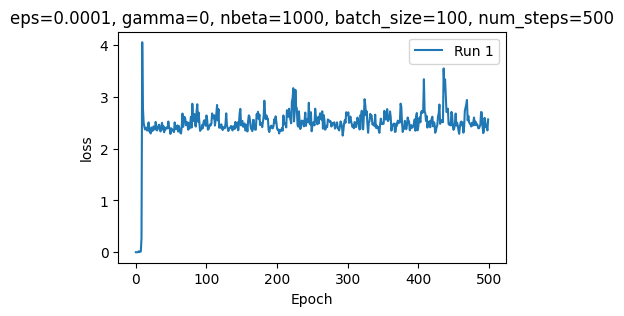

In [162]:
from palamedes.viz import plot_sgld_metric


plot_sgld_metric([sgld_dict], "loss", "SGLD loss").show()

### Loss function replaced with |w|^2

In [181]:
from palamedes.sgld_sampler import *

# set nbeta to zero and gamma nonzero to get quadratic energy
# we'll be treating gamma as our "beta"
params = SGLDParams(
    eps=1e-5,  # total step size
    gamma=10_000,  # localization term
    batch_size=100,  # batch size
    nbeta=0,  # this is not beta, but beta * n, where n= |whole dataset|
    num_steps=100,  # number of steps
    checkpoint_every=None,  # If integer, saves weights every checkpoint_every steps
    save_dir=None,  # if not specified, it defaults to /mnt/ssd-1/louis/palamedes/sgld_samples/{current_time}
    #device=device,
)
model = models_clean[-1]

sgld_dict = sgld(
    model,  
    params,
    dataset=[clean_ds, clean_ds_labels],
    cost_fn="zero",  # don't do forward pass, we only need the quadratic term
    device=device,
)

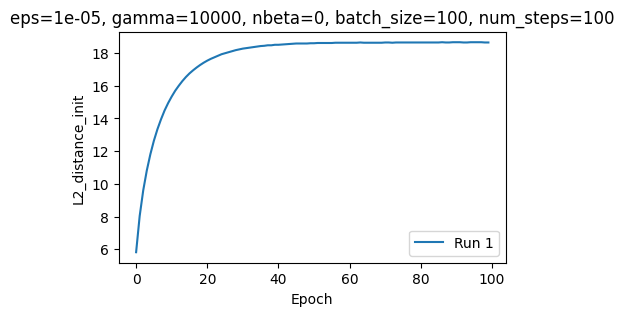

In [182]:
from palamedes.viz import plot_sgld_metric


plot_sgld_metric([sgld_dict], "L2_distance_init", "L2 distance to initialization").show()

In [187]:
# mean energy after burn-in
1/2 * (np.array(sgld_dict["L2_distance_init"][-30:])**2).mean()

np.float64(173.80444742838543)

### sweep for quadratic energy ("gamma" is beta)

In [98]:
model_dim = int(t.nn.utils.parameters_to_vector(model.parameters()).shape[0])

In [48]:
def sgld_quad_energy(gamma: float):
    params = SGLDParams(
        eps=1e-1 / gamma,  # total step size
        gamma=gamma,  # localization term
        batch_size=100,  # batch size
        nbeta=0,  # this is not beta, but beta * n, where n= |whole dataset|
        num_steps=100,  # number of steps
        checkpoint_every=None,  # If integer, saves weights every checkpoint_every steps
        save_dir=None,  # if not specified, it defaults to /mnt/ssd-1/louis/palamedes/sgld_samples/{current_time}
        #device=device,
    )
    model = models_clean[-1]

    sgld_dict = sgld(
        model,  
        params,
        dataset=[clean_ds, clean_ds_labels],
        cost_fn="zero",
        device=device,
    )

    return 1/2 * (np.array(sgld_dict["L2_distance_init"][-30:])**2).mean()

In [142]:
gammas = np.logspace(0, 5, 50)

energies = np.array([sgld_quad_energy(gamma) for gamma in gammas])



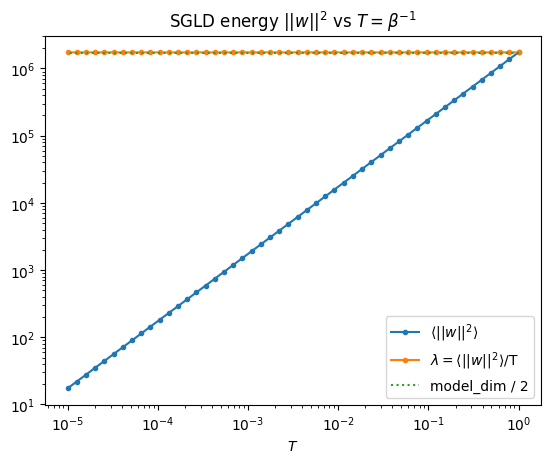

In [188]:
# plot energy vs T, and lambda

plt.plot(1/gammas, energies, '.-', label="$\\langle ||w||^2 \\rangle$")
plt.plot(1/gammas, gammas * energies, '.-', label="$\\lambda = \\langle ||w||^2 \\rangle$/T")
plt.plot(1/gammas, model_dim / 2 * np.ones_like(gammas), ':', label="model_dim / 2")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("$T$")
plt.legend()
plt.title("SGLD energy $||w||^2$ vs $T=\\beta^{-1}$")
plt.show()

In [145]:
# integrate -log Z

# we have samples of energy = d(-log Z) / d(gamma) at different gammas

# so we can integrate to get -log Z

# take means of consecutive energy samples to get a better estimate of slope
slopes = (energies[1:] + energies[:-1]) / 2

# compute bin widths for "numeric integration"
Dgammas = gammas[1:] - gammas[:-1]

# "numeric integration" to get -log Z
Dlog_Z = np.cumsum(slopes * Dgammas)

In [146]:
Dlog_Z[-1]

np.float64(20186765.84315038)

In [147]:
# theoretical prediction: N / 2 * np.log(gamma_max / gamma_min)
model_dim / 2 * np.log(gammas[-1] / gammas[0])

np.float64(19507558.47247288)

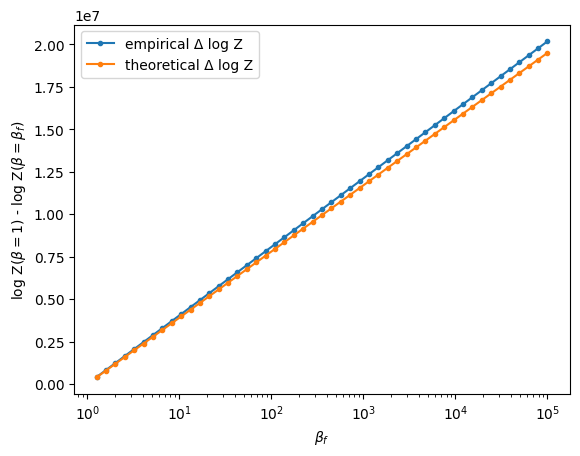

In [ ]:
# thermodynamic integration

plt.plot(gammas[1:], Dlog_Z, '.-', label="empirical Δ log Z")
plt.plot(gammas[1:], model_dim / 2 * np.log(gammas[1:] / gammas[0]), '.-', label="theoretical Δ log Z")
plt.xscale("log")
plt.xlabel("$\\beta_f$")
plt.ylabel("log Z($\\beta=1$) - log Z($\\beta=\\beta_f$)")
plt.legend()

### SGLD sweep

In [12]:
from palamedes.hyperparameter_sweep import sweep

model = models_clean[-1]

hyperparameters_sweep = {
    "eps": [1e-5, 1e-4, 1e-3],
    "nbeta": [1, 1e3, 1e5],
    "batch_size": [10, 100],
    "gamma": [0, 1],
    "num_steps": [1],
}

sweep(
    model=model,
    dataset=[clean_ds, clean_ds_labels],
    hyperparameters_sweep=hyperparameters_sweep,
    chains=2,
    device=device,
)

Data and model loaded
2025-02-26_20-56-10
Hyperparameters saved
Saved SGLD samples to /mnt/ssd-1/louis/palamedes/sgld_samples/2025-02-26_20-56-10


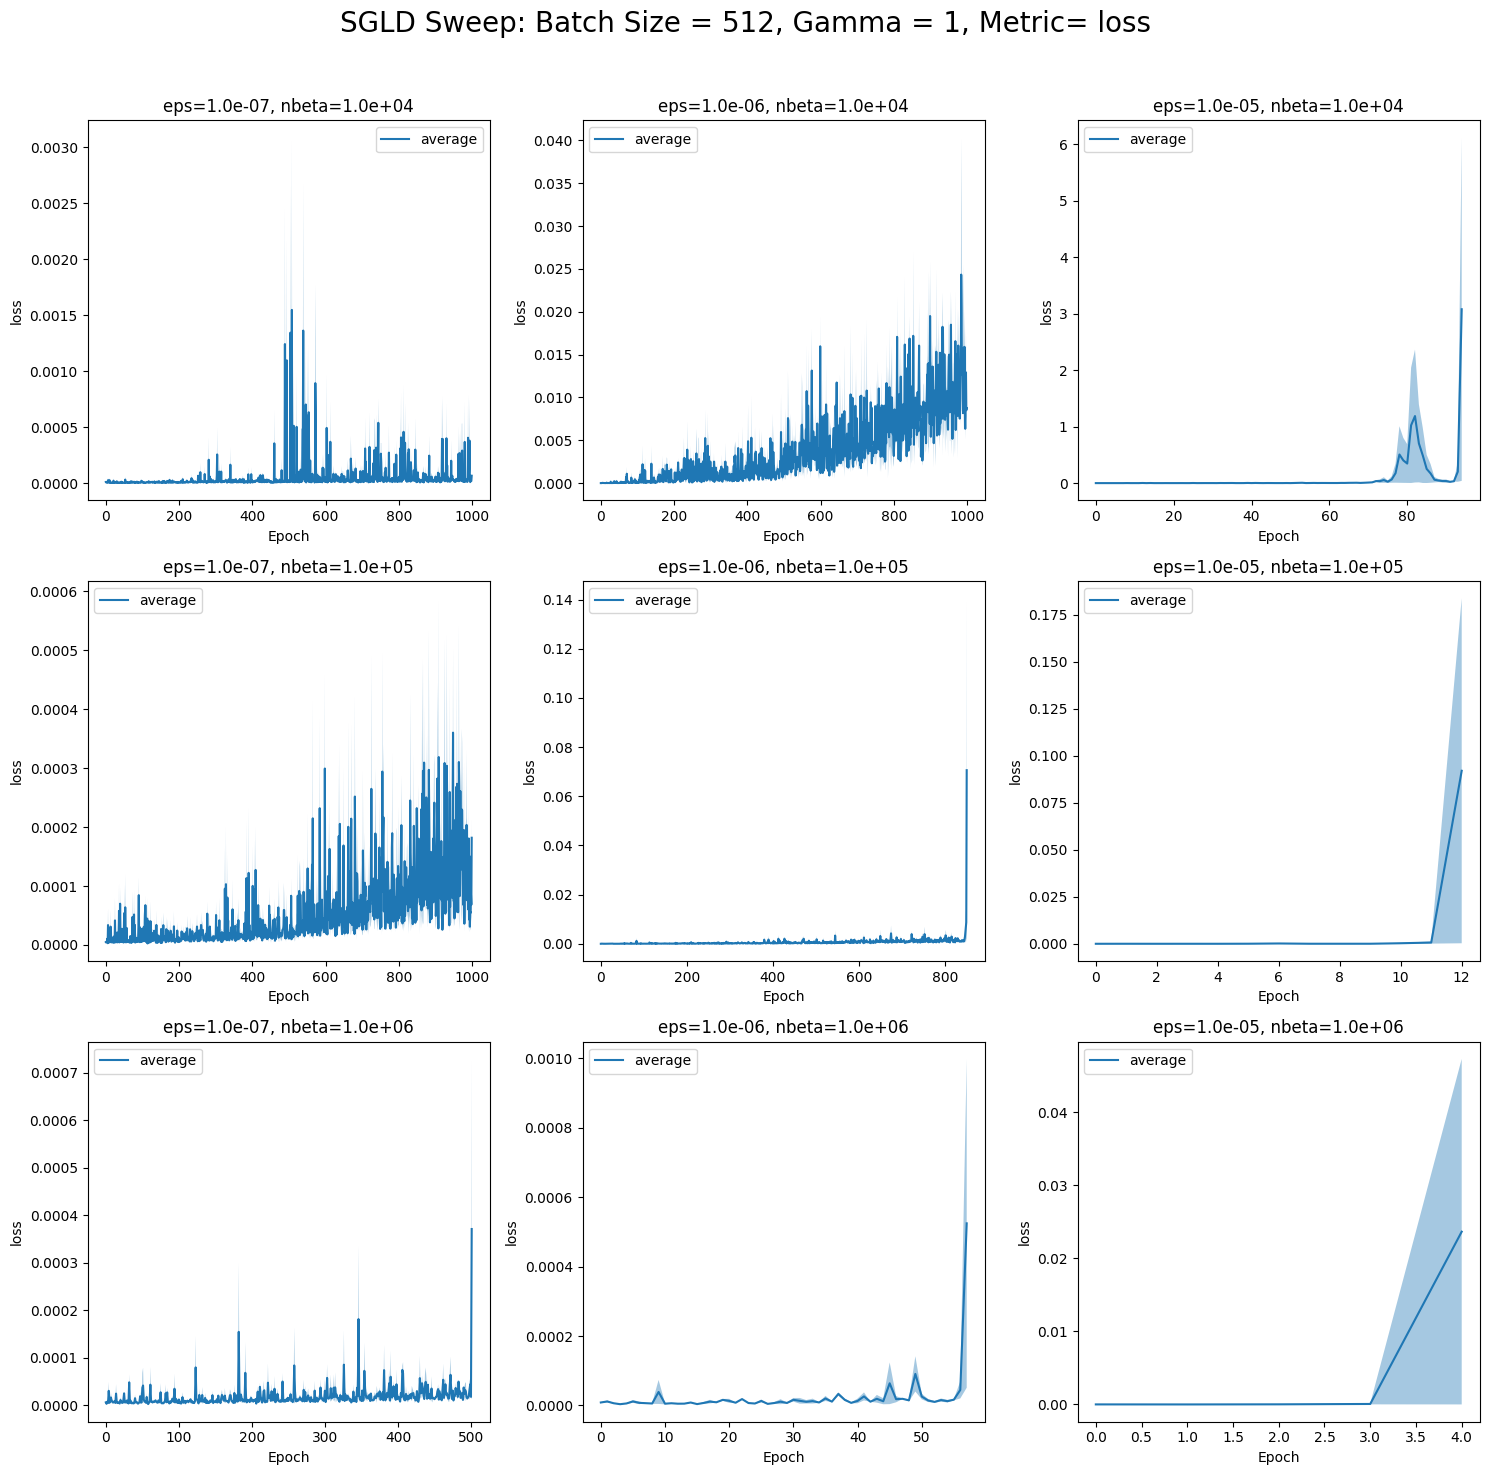

In [17]:
from palamedes.viz import plot_sgld_sweep


dir_path_sweep = "/mnt/ssd-1/louis/palamedes/sgld_samples/2025-02-26_15-34-46"

plot_sgld_sweep(
    dir_path=dir_path_sweep, batch_size=512, gamma=1, metric="loss", average=True
).show()

### SGLD radius

In [27]:
from palamedes.sgld_sampler import *

params = SGLDParams(
    eps=1e-4,  # total step size
    gamma=0,  # localization term
    batch_size=100,  # batch size
    nbeta=1000,  # this is not beta, but beta * n, where n= |whole dataset|
    num_steps=1000,  # number of steps
    checkpoint_every=100,  # If integer, saves weights every checkpoint_every steps
    save_dir=None,
)
model = models_clean[-1]

sgld_dict = sgld(
    model,
    params,
    dataset=[val_ds, val_ds_labels],
    cost_fn="KL",
    device=device,
)

Saving to /mnt/ssd-1/louis/palamedes/sgld_samples/2025-02-26_18-24-41


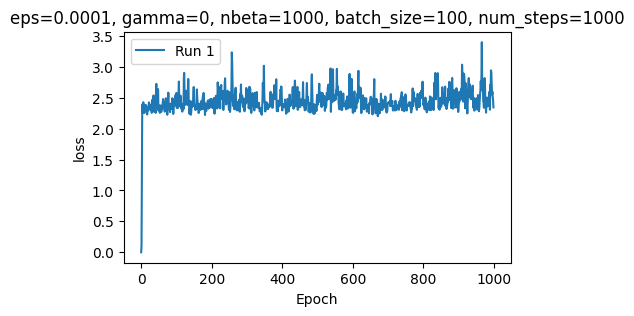

In [29]:
from palamedes.viz import plot_sgld_metric


plot_sgld_metric([sgld_dict], "loss", "SGLD loss").show()

In [30]:
sgld_dir = "/mnt/ssd-1/louis/palamedes/sgld_samples/2025-02-26_18-24-41"

import os

sgld_files = [
    os.path.join(sgld_dir, f) for f in os.listdir(sgld_dir) if f.endswith(".pt")
]

sgld_files = sorted(sgld_files, key=lambda x: int(x.split("_")[-1].split(".")[0]))

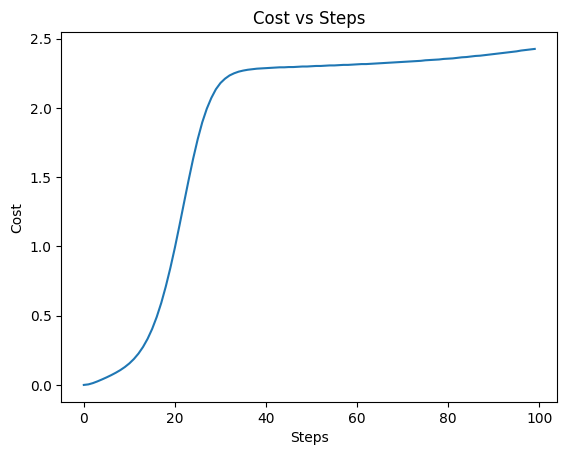

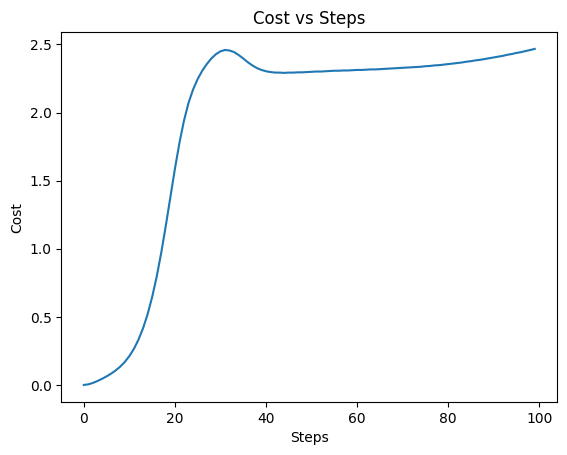

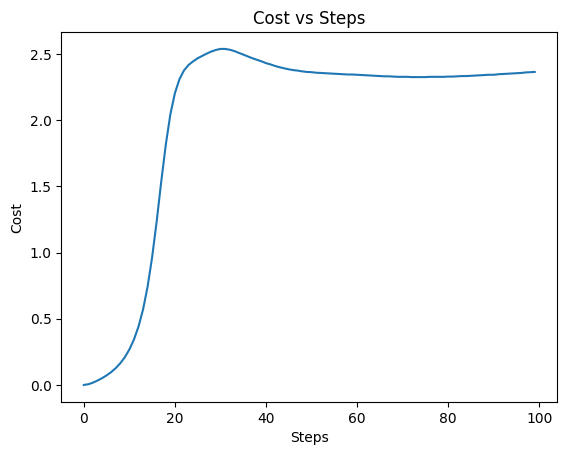

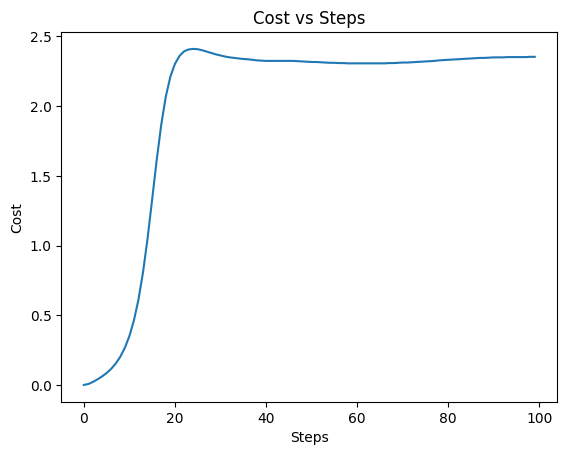

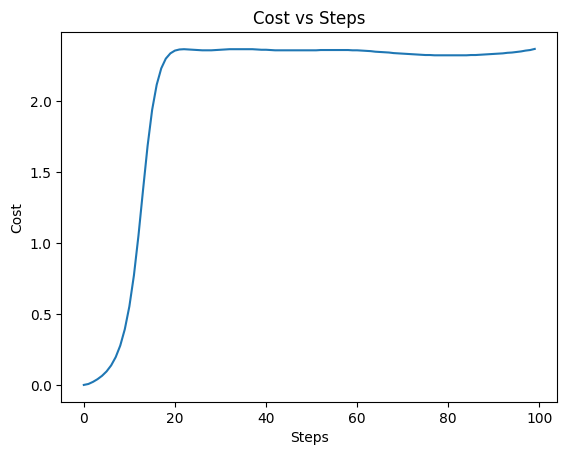

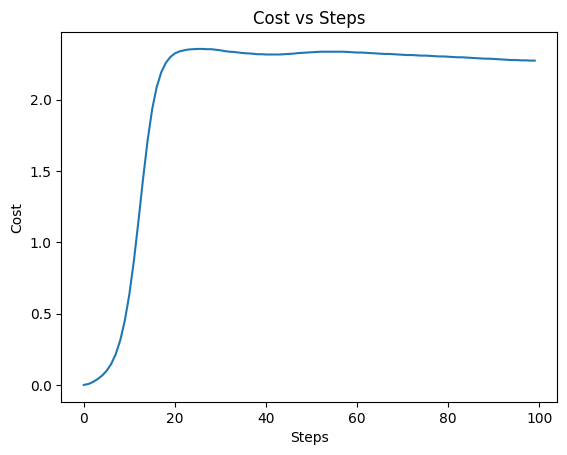

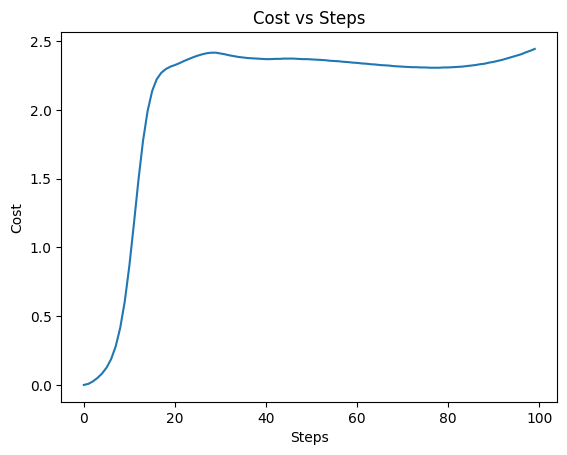

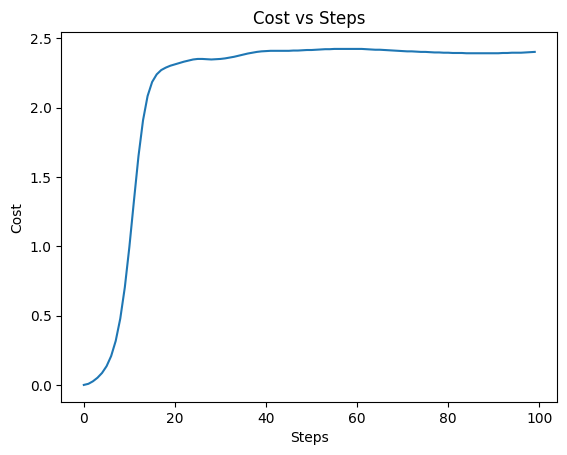

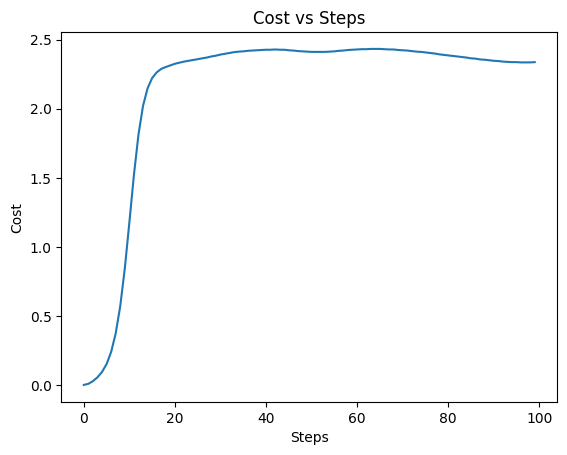

In [34]:
from palamedes.radius import plot_direction_cost

center = t.load(sgld_files[0], map_location=device)

for i in range(1, len(sgld_files)):
    direction = t.load(sgld_files[i], map_location=device) - center

    plot_direction_cost(
        model=model,
        center=center,
        direction=direction,
        dataset=val_ds,
        device=device,
        mult=1,
        cost_fn=logit_loss,
        cutoff=0,
    )